In [ ]:
#| hide
import numpy as np
import matplotlib.pyplot as plt
import torch

In this notebook, we will explore generative modelling, the branch of machine learning that has perhaps seen the biggest advances in the last couple of years, fueled by the advent of larger language models (LLM). The goal in all cases is the following: we are given some dataset $X$, sample from a given distribution $p(x)$. Our goal is to create a model whose distribution $p_\theta(x) \approx p(x)$. Once we have such a model, we can sample from it to generate new data points that resemble the original dataset.

# Maximum likelihood estimation

Maximum Likelihood Estimation (MLE) is the classical starting point of generative modeling. Given a parametric family of probability distributions $p_\theta(x)$, the goal is to learn parameters $\theta$ such that the model assigns high probability to the observed data. This is achieved by maximizing the (average) log-likelihood of the dataset, which minimize the distance between our model and the empirical distribution of the data:
$${\theta}^* = \text{arg}\,\text{min}_{{\theta}} D_{KL}(\hat{p}_{\text{data}}||p_{{\theta}}) = \text{arg}\,\text{min}_{{\theta}} -\mathbb{E}_{x\sim\hat{p}_{\text{data}}}\left[\log p_{{\theta}}(x)\right]\,.$$
We can recognize here the negative log-likelihood loss function that we have previously seen in the course, which is the cross entropy between the empirical distribution and the one defined by the model, as we introduced in the [logistic regression section](../linear_models/03_logistic_regression.ipynb).

ML is **the most statistically efficient** estimator. This means that no other estimator achieves a lower mean squared error (MSE) than the MLE for a fixed number of samples. Furthermore, it is **consistent**, which guarantees that it converges to the true value as we increase the number of data points, under two conditions:

- $p_{\text{data}}$ lies within the hypothesis space of $p_{{\theta}}$.
- $p_{\text{data}}$ corresponds to a unique ${\theta}$.

## Example
Let's consider a small example to understand how this works. We will consider for that that our $p_\theta$ is a mixture of two Gaussians. For simplicity, and allow our model to properly converge, we will also consider that our dataset is samples for a mixture of Gaussian. Let's consider for that the following class, that will help both generate the data and define our model:

In [ ]:
#| code-fold: true
class GaussianMixture:
    def __init__(self, phi, mu_0, std_0, mu_1, std_1):
        """Initialize a Gaussian mixture with two modes. `phi` denotes
        the probability to sample from distribution 1."""
        self.phi = phi
        self.mu_0, self.std_0 = mu_0, std_0
        self.mu_1, self.std_1 = mu_1, std_1

    def sample(self, n_samples):
        "Draw samples from a Gaussian mixture model."
        which = np.random.uniform(size=n_samples) < self.phi
        samples_0 = np.random.normal(self.mu_0, self.std_0, n_samples)
        samples_1 = np.random.normal(self.mu_1, self.std_1, n_samples)
        return np.where(which, samples_1, samples_0)

    def pdf(self, x):
        "Evaluate the Gaussian mixture pdf over x."
        pdf_0 = self.gaussian_pdf(x, self.mu_0, self.std_0)
        pdf_1 = self.gaussian_pdf(x, self.mu_1, self.std_1)
        return (1-self.phi)*pdf_0 + self.phi*pdf_1
    
    @staticmethod
    def gaussian_pdf(x, mu, std):
        return np.exp(-(x-mu)**2/(2*std**2))/(std*np.sqrt(2*np.pi))

Let's now use it to generate our dataset:

In [ ]:
# Parameters of the mixture of Gaussians
phi, mu_0, std_0, mu_1, std_1 = 0.7, 5, 2, 20, 3
# Parameters of the datasets
size_train, size_test = 500, 500
np.random.seed(0) # for reproducibility

# Now we generate our data
mixture = GaussianMixture(phi, mu_0, std_0, mu_1, std_1)
x_train = np.round(mixture.sample(size_train)).astype(int)
x_test = np.round(mixture.sample(size_test)).astype(int)

We can visualize the dataset as follows:

<matplotlib.legend.Legend>

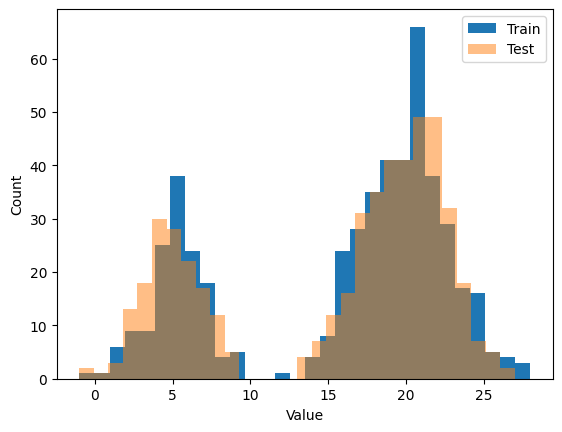

In [ ]:
plt.hist(x_train, bins = 30, label = 'Train')
plt.hist(x_test, bins = 30, alpha = 0.5, label = 'Test')
plt.xlabel("Value"); plt.ylabel("Count"); plt.legend()

Next, we define the loss function for the training data, considering that our $p_\theta$ is the mixture of Gaussians. Since we deal with a fairly low amount of data, we can compute the loss for the whole training set at once.

In [ ]:
def mle_train_loss(params):
    phi, mu_0, std_0, mu_1, std_1 = params
    pdf_0 = mixture.gaussian_pdf(x_train, mu_0, std_0)
    pdf_1 = mixture.gaussian_pdf(x_train, mu_1, std_1)
    log_likelihood = np.log((1-phi)*pdf_0 + phi*pdf_1)
    return -np.mean(log_likelihood)

Now we can simply use a [scipy optimizer](https://docs.scipy.org/doc/scipy/reference/optimize.html) to find the minimum.

In [ ]:
from scipy.optimize import minimize

initial_parameters = np.array([0.5, 5., 3., 15., 3.])
result = minimize(mle_train_loss, x0=initial_parameters, bounds=[(0, 1), (0, 25), (0, 5), (0, 25), (0, 5)])

In [ ]:
#| code-fold: true
print("The parameters are:")
print(f"\tGround truth: phi={mixture.phi:.2f}, mu_0={mixture.mu_0:.2f},"+
      f" std_0={mixture.std_0:.2f}, mu_1={mixture.mu_1:.2f}, std_1={mixture.std_1:.2f}")
print(f"\tEstimation:   phi={result.x[0]:.2f}, mu_0={result.x[1]:.2f},"+
      f" std_0={result.x[2]:.2f}, mu_1={result.x[3]:.2f}, std_1={result.x[4]:.2f}")

The parameters are:
	Ground truth: phi=0.70, mu_0=5.00, std_0=2.00, mu_1=20.00, std_1=3.00
	Estimation:   phi=0.72, mu_0=4.91, std_0=1.91, mu_1=20.27, std_1=2.85


As you can see, the estimation is quite good, and we ended almost reaching the groundtruth values. Nonetheless, as you may have guessed, this approach quickly becomes impractical in higher dimensions or with more complex models. First, we are relying here on a model for which we can compute the probability density function (pdf) in closed form. While this is good for optimization in small models, it hinders the expressivity of the model. Indeed, the optimization itself becomes quickly intractable as the number of parameters increases.

In the following, we will explore other parametrization of $p_\theta(x)$ that allow us to scale to larger models and datasets.

# Boltzmann Machines

Boltzmann machines (BM) are one of the earliest generative models, and are deeply connected to statistical phyics. Indeed, strictly speaking, a BM is based on the stochastic Ising model you have probably seen in a statistical physics course. They were later related learning first by John Hopfield ([1982](https://pmc.ncbi.nlm.nih.gov/articles/PMC346238/)) and later by Geoffrey Hinton ([1983](https://www.cs.utoronto.ca/~hinton/absps/fahlmanBM.pdf)). If these two names are familiar to you is probably because they got the Nobel Prize in 2024 for setting up the foundations of deep learning. If you want to know more about their work, I highly recommend reading the Nobel Prize's [scientific background](https://www.nobelprize.org/prizes/physics/2024/advanced-information/).

The main idea behind Boltzmann Machines is to define a probability distribution over binary variables $x \in \{0,1\}^D$ through an energy function $E_\theta(\sigma)$, where $\sigma$ denotes a configuration of the system. Although Boltzmann Machines can also be formulated for continuous variables, we restrict ourselves here, for simplicity, to the case of binary units. The configurations consists of two sets of units, $\sigma = (v,h)$: the visible variables $v$, which represent the observed data $x$, and the hidden variables $h$, which are introduced to capture complex dependencies among the visible variables.


::: {#fig-mdp}
<img src="../../figures/bm.svg" width="30%"/>

Fully connected Boltzmann Machine with visible variables $v$ and hidden variables $h$.

:::

The energy function of such BM is then given by
\begin{equation}
E_\theta(\sigma) = - \sum_{i, j} W_{ij} \sigma_i \sigma_j - \sum_i b_i \sigma_i,
\end{equation}

The joint distribution over visible and hidden variables (i.e. the full configuration) is defined as
\begin{equation}
P_\theta(\sigma) = \frac{1}{Z_\theta}\, e^{-E_\theta(\sigma)},
\end{equation}
where $Z_\theta$ is the partition function
\begin{equation}
Z_\theta = \sum_{\sigma} e^{-E_\theta(\sigma)}.
\end{equation}

In practice, we are not interested in the full distribution over visible and hidden variables, but rather in the marginal distribution over visible variables:

\begin{equation}
p_\theta(v) = \sum_{h} P_\theta(\sigma = (v, h)) = \frac{1}{Z_\theta} \sum_{h} e^{-E_\theta(v, h)}.
\end{equation}

With that, we have defined our model $p_\theta$, which we now want to use to approximate the dataset's distribution $p_{\text{data}}(x)$. To do so, we can use maximum likelihood estimation as before, which corresponds to minimizing the negative the log-likelihood of the data under the model:

\begin{equation}
\mathcal{L}(\theta) = -\sum_{x \in X} p_{\text{data}}(x) \log p_\theta(x).
\end{equation}
where $X$ is our dataset.

Given this, we now perform gradient descent to minimize the loss. As you can see from the previous equation, $p_{\text{data}}$ is independent on the training parameters, hence the minimization is only performed to $\log p_\theta$. It can be shown that the derivative of this term with respect to a parameter $\theta$ is given by
\begin{equation}
\partial_\theta \left( -\log p_\theta(v) \right)= \left<\partial_\theta E_\theta\right>_{\text{data}} - \left<\partial_\theta E_\theta\right >_{\text{model}},
\end{equation} 
where the bracket $\left <· \right>$ denotes the expectation value with respect to the probability distributions $p_{\text{data}}$ or $p_\theta$ for the data and model averages, respectively. The first term is called the positive phase, and the second term the negative phase. One of the main challenges when dealining with this models is computing these two terms, which is typically untractable. To deal with this issue, one typically resorts to approximate sampling methods such as Markov Chain Monte Carlo (MCMC) or contrastive divergence.

## Restricted Boltzmann machines

One way to simplify the learning and sampling procedure in Boltzmann machines is to restrict the interaction structure between visible and hidden units. For instance, one can consider a bipartite graph structure, where visible units only interact with hidden units, and vice versa. This leads to the concept of Restricted Boltzmann Machines (RBMs), which were one of the earliest and most studied generative models in machine learning.


::: {#fig-mdp}
<img src="../../figures/rbm.svg" width="30%"/>

Restricted Boltzmann Machine with weights $w_{ij}$ and biases $b_j$ and $a_i$ for hidden and visible units, respectively.
:::

One of the nice simplifications when considering this bipartite structe is that $\partial w_{ij} E_\theta = -v_i h_j$. In this way, the gradient of the negative log-likelihood with respect to the weights $W_{ij}$ can be expressed as
\begin{equation}
\partial_{W_{ij}} \left( -\log p_\theta(v) \right)= \left< v_i h_j \right>_{\text{data}} - \left< v_i h_j \right >_{\text{model}}.
\end{equation}
Similarly, the gradient with respect to the biases of the visible units $a_i$ and hidden units $b_j$ are given by
\begin{align}
\partial_{a_{i}} \left( -\log p_\theta(v) \right) &= \left< v_i \right>_{\text{data}} - \left< v_i \right >_{\text{model}}, \\
\partial_{b_{j}} \left( -\log p_\theta(v) \right) &= \left< h_j \right>_{\text{data}} - \left< h_j \right >_{\text{model}}.
\end{align}

Moreover, with this structure, the conditional distributions $p_\theta(h|v)$ and $p_\theta(v|h)$ become factorized, allowing for efficient Gibbs sampling. Specifically, the conditional distributions of a given hidden unit being 1 can be expressed as:
\begin{equation}
p_\theta(h_j=1|v) = \sigma\left(\sum_{i} W_{ij} v_i + b_j\right),
\end{equation}
where $\sigma(x) = 1/(1 + e^{-x})$ is the sigmoid function. Conversely, the conditional probability of a visible unit being 1 given the hidden units is:
\begin{equation}
p_\theta(v_i=1|h) = \sigma\left(\sum_{j} W_{ij} h_j + a_i\right),
\end{equation}

From this, we can see that the positive phase on the gradient can be computed exactly, as it only involves sampling from the conditional distribution $p_\theta(h|v)$. The negative phase, on the other hand, requires sampling from the full joint distribution $P_\theta(\sigma)$. However, thanks to the bipartite structure, we can efficiently approximate it using a finite number of Gibbs sampling steps, alternating from the visible to the hidden, leading to efficient training algorithms such as Contrastive Divergence (CD). The latter works as follows:

1. For each data point $v^{(0)}$ in the dataset, sample the hidden units $h^{(0)}$ from the conditional distribution $p_\theta(h|v^{(0)})$. While one could start with a random configuration, starting from the data point itself often leads to faster convergence.
2. Sample a new visible configuration $v^{(1)}$ from the conditional distribution $p_\theta(v|h^{(0)})$.
3. Repeat steps 1 and 2 for a fixed number of iterations $k$ to obtain $v^{(k)}$ and $h^{(k)}$.


::: {.callout-tip}

## Exercise
The goal of this exercise is to create a training loop for an RBM with binary units, i.e. $v_i, h_j \in \{0, 1\}$. The goal is not to do a full training but rather to implement the concepts we introduced above. Your first task is to implementing the conditional probabilities for the hidden and visible units as functions (based on `torch`). *Tip:* you can use `torch.matmul` for matrix multiplication between inputs and weights, and `torch.sigmoid` for the sigmoid activation function.

In [ ]:
# Your code here
def prob_h_from_v(v, W, b):
    """Compute the conditional probability P(h|v) in an RBM."""
    
    return h

def prob_v_from_h(h, W, a):
    """Compute the conditional probability P(v|h) in an RBM."""
    
    return v

In [ ]:
# Use this code to test your function
dim_v = 10
dim_h = 3

W = torch.randn(dim_v, dim_h)
a = torch.randn(dim_v); b = torch.randn(dim_h)

p_h = prob_h_from_v(torch.ones(1, dim_v), W, b)
p_v = prob_v_from_h(torch.ones(1, dim_h), W, a)

assert p_h.shape[1] == dim_h
assert p_v.shape[1] == dim_v

p_h, p_v

(tensor([[0.3706, 0.1061, 0.0429]]),
 tensor([[0.9292, 0.1377, 0.2243, 0.0839, 0.3749, 0.2288, 0.8154, 0.8358, 0.1229,
          0.8982]]))

Now that you have these two functions, you can implement a single step of Gibbs sampling. Your task is to implement the function `gibbs_step`, which takes as input a visible configuration `v`, the weights `W`, and the biases `a` and `b`, and returns a new visible configuration after one Gibbs sampling step. *Tip:* remember that after computing the conditional probabilities, you need to sample from a Bernoulli distribution to obtain binary values for the units.

In [ ]:
# Your code here
def gibbs_step(v, W, a, b):
    """Perform one step of Gibbs sampling in an RBM."""
    # first comput prob of hidden:
    p_h = ...
    # then sample using bernoulli distribution
    h = torch.bernoulli(p_h)

    # From here compute prob of visible and sample again with bernoulli
    
    return v_new

In [ ]:
# Use this code to test your function
v = torch.ones(1, dim_v)

W = torch.randn(dim_v, dim_h)
a = torch.randn(dim_v); b = torch.randn(dim_h)

v_new = gibbs_step(v, W, a, b)

assert (v != v_new).any()

v, v_new

(tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]),
 tensor([[0., 0., 1., 0., 0., 0., 1., 1., 1., 1.]]))

Next, you can implement the positive and negative phases of the gradient. Your task is to implement the function `compute_gradients`, which takes as input a batch of visible configurations `v_batch`, the weights `W`, and the biases `a` and `b`, and returns the gradients with respect to `W`, `a`, and `b`. *Tip:* for the negative phase, you will need to use CD, i.e. use $k$ times the `gibbs_step` function you implemented earlier to sample from the model distribution.

In [ ]:
# Use this code to test your function 

# We create a dataset of samples
v = torch.randint(0, 2, (100, dim_v)).float()

# Define our model
W = torch.randn(dim_v, dim_h)
a = torch.randn(dim_v); b = torch.randn(dim_h)

# Compute the gradients
W_grad, a_grad, b_grad = compute_gradients(v, W, a, b, k=5) 

W_grad, a_grad, b_grad

(tensor([[-0.2000, -0.1100, -0.1900],
         [-0.2600, -0.2000, -0.2400],
         [-0.2200, -0.1300, -0.2400],
         [-0.1800, -0.1300, -0.1900],
         [-0.0200,  0.0300, -0.0200],
         [ 0.1900,  0.1600,  0.1700],
         [-0.2900, -0.1500, -0.3000],
         [-0.2400, -0.1700, -0.2500],
         [-0.3100, -0.2300, -0.3000],
         [ 0.1600,  0.1500,  0.1500]]),
 tensor([-0.1900, -0.2500, -0.2200, -0.1700,  0.0000,  0.2000, -0.2900, -0.2400,
         -0.3000,  0.1700]),
 tensor([-0.0200, -0.0100, -0.0300]))

:::

# Variational Autoencoders

When exploring unsupervised methods, we took a look at autoencoders (AE). Autoencoders learn to compress data into a low-dimensional latent representation and reconstruct the input from it by minimizing a reconstruction error. While this provides a powerful nonlinear alternative to methods such as PCA, standard autoencoders learn an unconstrained latent space, which is often irregular and poorly suited for sampling or interpretation.

Variational Autoencoders (VAEs) overcome this limitation by giving the latent space a probabilistic structure. Instead of encoding each input as a single point, the encoder outputs a distribution over latent variables, which is encouraged during training to match a simple prior, typically a standard normal distribution. This regularization makes the latent space smooth and continuous.

This probabilistic formulation naturally turns VAEs into generative models. Once trained, new data can be generated by sampling latent variables from the prior and passing them through the decoder. At the same time, VAEs retain the representation-learning capabilities of autoencoders, learning compact latent variables that capture the essential structure of the data. In physics and other scientific applications, this makes VAEs particularly useful for uncovering meaningful low-dimensional descriptions while enabling controlled data generation.

## Architecture

::: {#fig-mdp}
<img src="../../figures/vae.svg" width="30%"/>

Variational Autoencoder
:::

Just as the AE, VAEs consist of an encoder, latent space and a decoder. The encoder maps input data $x$ to a distribution $z$ in the latent space. To do so in a efficient and trainable way, the encoder typically outputs the parameters of the chosen latent distribution, which in almost all cases is a Gaussian. This is known as the *Reparametrization Trick*. Specifically, for each latent neuron $z_i$, the encoder outputs a mean $\mu_i(x)$ and variance $\sigma_i^2(x)$. Note that, in practice, the encoder rather outputs the log-variance $\log \sigma_i^2(x)$ for numerical stability.

As every latent neuron is conditionally independent from each other, the latent space corresponds to a multi-variate Gaussian with diagonal covariance matrix, whose distribution can be expressed $q_\phi(z|x) = \mathcal{N}(z; \mu(x), \text{diag}(\sigma^2(x)))$. During training, we sample $z$ from this distribution using the reparametrization trick: we first sample $\epsilon \sim \mathcal{N}(0, I)$ and then compute, for all $z_i$, $z_i = \mu_i(x) + \sigma_i(x) \odot \epsilon$, where $\odot$ denotes element-wise multiplication. Then, the sampled latent space is fed in the decoder to generate the reconstructed input $\hat{x}$. The decoder hence defines a distribution $p_\theta(x|z)$ over the input space.


## Loss
The goal of VAE, as in all previous cases, is to approximate the data distribution $p_{\text{data}}(x)$ via the maximizing the log-likelihood $\log p_\theta(x)$. However, in this case, computing this term directly is intractable, as it requires integrating over all possible latent variables:

\begin{equation}
\log p_\theta(x) = \log \int p_\theta(x|z) p(z) dz.
\end{equation}
Instead, we optimize a lower bound on the log-likelihood, known as the Evidence Lower Bound (ELBO):
\begin{equation}
\log p_\theta(x) \geq \mathcal{L}_{\text{ELBO}} = \mathbb{E}_{z \sim q_\phi(z|x)} [\log p_\theta(x|z)] - D_{KL}(q_\phi(z|x) || p(z)).
\end{equation}

The ELBO above contains two terms:

1. Reconstruction term $\mathcal{L}_r = \mathbb{E}_{z \sim q_\phi(z|x)} [\log p_\theta(x|z)]$: This is the expected log-likelihood of the data given the latent variables sampled from the encoder's distribution. It encourages the decoder to reconstruct the input data accurately from the latent representation. In most cases, the previous term is implemented as a standard reconstruction loss, such as mean squared error (MSE) for continuous data or binary cross-entropy for binary data.
2. Latent term $\mathcal{L}_z = - D_{KL}(q_\phi(z|x) || p(z))$: This is the Kullback-Leibler divergence between the encoder's distribution $q_\phi(z|x)$ and the uninformed prior distribution $p(z)$, typically chosen to be $p(z) = \mathcal{N}(0,1)$, i.e. a standard normal distribution with mean zero and variance one. This term acts as a regularizer, encouraging the learned latent distribution to be close to the prior, which promotes smoothness and continuity in the latent space.
On the other hand, by choosing both the prior $p(z)$ and the encoder distribution $q_\phi(z|x)$ as Gaussian distributions, we can compute the KL divergence in closed form:
\begin{equation}
\mathcal{L}_z = \frac{1}{2} \sum_{i=1}^{d} \left(1 + \log \sigma_i^2(x) - \sigma_i^2(x) - \mu_i^2(x) \right),
\end{equation}
where $d$ is the dimensionality of the latent space.

## Interpretability in VAEs
The balance between the reconstruction and latent terms in the ELBO is crucial for learning meaningful and interpretable latent representations in VAEs. A strong emphasis on the reconstruction term can lead to overfitting, where the model memorizes the training data without capturing the underlying structure. Conversely, a dominant latent term may result in poor reconstructions, as the model prioritizes matching the prior over accurately representing the data.

Recently, a variant known as the $\beta$-VAE has been proposed ([Higgins et al. (2007)](https://openreview.net/forum?id=Sy2fzU9gl)), which introduces a hyperparameter $\beta$ to weight the latent term:
\begin{equation}
\mathcal{L} = \mathbb{E}_{z \sim q_\phi(z|x)} [\log p_\theta(x|z)] - \beta D_{KL}(q_\phi(z|x) || p(z)).
\end{equation}

This modification allows for greater control over the trade-off between reconstruction fidelity and latent space regularization. By tuning $\beta$, one can encourage the model to learn more disentangled and interpretable latent factors, which can be particularly beneficial in scientific applications where understanding the underlying generative factors is essential. 

This feature is specially useful in physics applications, where one often seeks to uncover latent variables that correspond to meaningful physical quantities. More to come on the presentation of the paper ["Discovering Physical Concepts with Neural Networks", Iten et al. (2020)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.124.010508).

::: {.callout-tip}

## Exercise - Generating MNIST

In this exercise we will implement what we just learned on VAEs to generate new instances of the MNIST dataset. Let's consider as architecture an extension ofthe fully convolutional AE used in the denoising example in the [unsupervised learning notebook](01_intro_to_unsup.ipynb). Your first task is to adapt the architecture to implement a convolutional VAE. Below I started the class, adding all necessary layers you will need, as well as the reparameterization trick. Your task is to create the forward pass. When creating VAEs it is always useful to separate in different methods the decode / encode operations as we did when create `Conv_AE` in the unsupervised notebook. You can use that implementation as a guide.

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        
        # Encoder: 1x28x28 -> 16x14x14 -> 32x7x7
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # -> 16x14x14
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # -> 32x7x7
            nn.ReLU(True)            
        )

        # Latent space
        self.enc_out_dim = 32 * 7 * 7
        self.fc_mu     = nn.Linear(self.enc_out_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.enc_out_dim, latent_dim)

        self.fc_z = nn.Linear(latent_dim, self.enc_out_dim)
        
        # Decoder: 32x7x7 -> 16x14x14 -> 1x28x28
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # -> 16x14x14
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),  # -> 1x28x28
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Your code here

        # because we need mus and logvars for the loss, we also
        # output them in the forward pass
        return x_reconstructed, mu, logvar

In [ ]:
# You can use this cell to test your implementation
data = torch.randn(4, 1, 28, 28)  # batch of 4 random images

vae = VAE(latent_dim=14)

assert vae(data)[0].shape == data.shape

Now that we have the architecture, its time to create the loss. In this case, we will use the MSE as reconstruction loss, as the images are grayscale. Your task is to implement a class that computes the ELBO loss we introduced before, similar as we did when studying the [regularization techniques](../deep_learning/03_regularization_techniques.ipynb).

In [ ]:
class vae_loss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, input, targets, beta = 1.0):

        preds, mu, logvar = input

        # Your code here!

        return L_r + beta * L_z

In [ ]:
# You can use this code to test your implementation
N = 5
preds = torch.ones(N, 1, 28, 28)
targets = torch.zeros(N, 1, 28, 28)

mu = torch.zeros(N, latent_dim)+0.1
sigma = torch.ones(N, latent_dim)

loss = vae_loss()
val = loss((preds, mu, torch.log(sigma**2)), targets)

assert torch.round(val, decimals = 1) == 1.4

We have now all the ingredients to train our network. We will make use of `fastai` to simplify the training loop. Below is the full code to train the VAE on MNIST and generate new samples.

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader
from fastai.vision.all import Learner, Adam, DataLoaders

train_dataset = datasets.MNIST(root="data", train=True, download=True, transform=transforms.ToTensor()).data.to(torch.float).unsqueeze(1)/255
test_dataset  = datasets.MNIST(root="data", train=False, download=True, transform=transforms.ToTensor()).data.to(torch.float).unsqueeze(1)/255

train_data = TensorDataset(train_dataset, train_dataset)
test_data = TensorDataset(test_dataset, test_dataset)

batch_size = 128

# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

data = DataLoaders(train_loader, val_loader)

# Then we create a Learner object, which bundles together the data, model, loss function and optimizer
latent_dim = 8
learner = Learner(data, VAE(latent_dim=latent_dim), loss_func = vae_loss(), opt_func=Adam)

# Finally we train the model using
learner.fit(20, lr = 1e-3)

epoch,train_loss,valid_loss,time
0,5179.431641,5079.499512,00:04
1,4594.440430,4530.152832,00:04
2,4366.184570,4327.264160,00:04
3,4279.003906,4238.279785,00:04
4,4188.517090,4177.915039,00:03
5,4148.207031,4149.649902,00:04
6,4109.821289,4112.739746,00:04
7,4097.979980,4069.386475,00:03
8,4075.793945,4050.415527,00:03
9,4069.058838,4028.198730,00:03


To test the generative capabilities of the model, you can reconstruct some images from the test set:

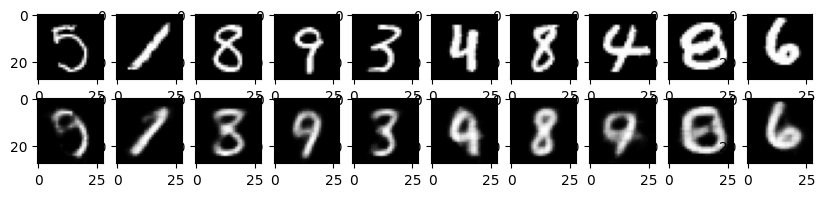

In [ ]:
targets = test_dataset[torch.randint(0, test_dataset.shape[0], (10,))]
preds_test = learner.model(targets.to('cuda'))[0].detach().cpu()

fig, ax = plt.subplots(2,10, figsize=(10,2))

for p, t, ax in zip(preds_test, targets, ax.transpose()):
    
    ax[0].imshow(t[0], cmap='gray')
    ax[1].imshow(p[0], cmap='gray')
    # ax.axis('off')


:::

## Extra: interpreting the latent space
As we mentioned before, one of the main advantages of VAEs is that they learn a structured latent space that can be interpreted. We will learn more about its use in physics later in the course. Here, we will just explore a bit how to visualize the latent space. A common approach is to look at the latent dimensions with highest variance, as they typically capture the most relevant features of the data. We can then vary these dimensions while keeping the others fixed to see how they affect the generated images. These types of plots are known as latent traversals.

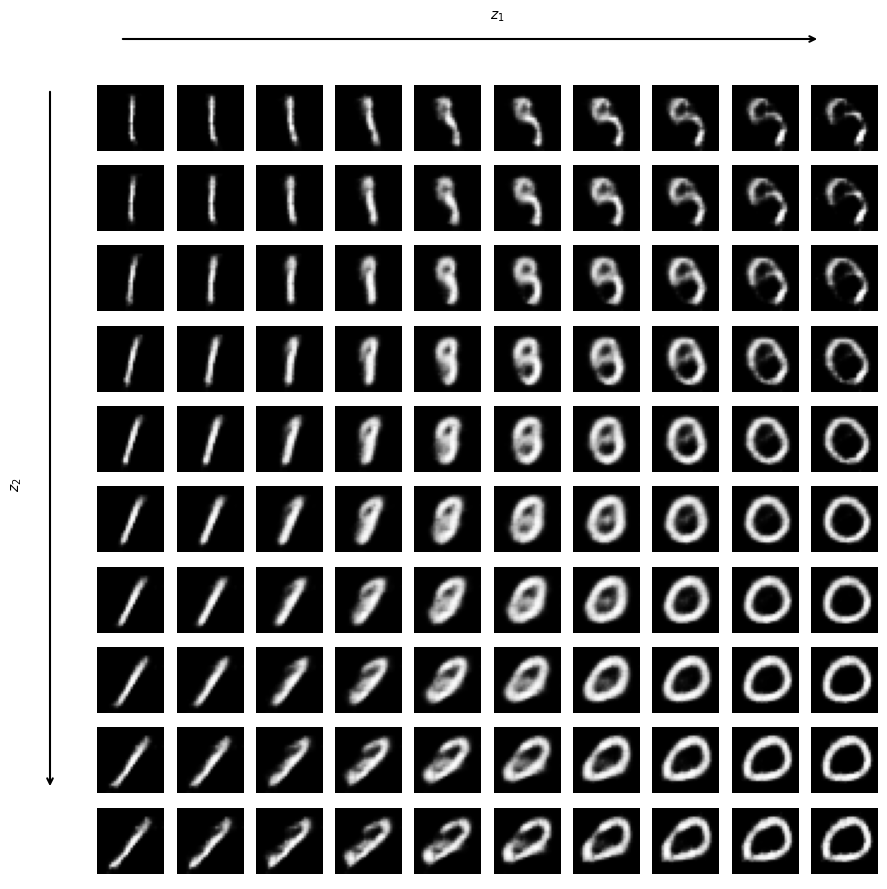

In [ ]:
#| code-fold: true
#| code-summary: Plot code - Latent traversal for most significant dimensions

# We identify the latent neurons with lowest logvar, i.e. the ones that receive less noise from the latent
logvar = learner.model(test_dataset.to('cuda'))[2].detach().cpu()
z_idx = logvar.mean(0).sort()[1][:2]

# Now we create a grid of images by varying these two latent dimensions
ns = 10
values_latent = torch.linspace(-3, 3, ns)

z = torch.zeros((ns*ns, latent_dim))
z[:, z_idx[0]] = values_latent.repeat(ns)
z[:, z_idx[1]] = values_latent.unsqueeze(1).repeat(1, ns).view(-1)

fig, ax = plt.subplots(ns, ns, figsize=(10,10))

for i in range(ns):
    for j in range(ns):
        z_ij = z[i*ns + j].unsqueeze(0).to('cuda')
        sample_ij = learner.model.decode(z_ij).detach().cpu()
        ax[i, j].imshow(sample_ij[0,0], cmap='gray')
        ax[i, j].axis('off')

###### Visual helpers #####
fig.subplots_adjust(top=0.9, left=0.12)

# ---- Top arrow ----
plt.annotate(
    '', xy=(0.82, 0.85), xytext=(0.12, 0.85),
    xycoords='figure fraction',
    arrowprops=dict(arrowstyle='->', lw=1.5),
    annotation_clip=False
)

plt.text(0.52, 0.96, r'$z_1$', ha='center', va='bottom',
         transform=fig.transFigure)

# ---- Left arrow ----
plt.annotate(
    '', xy=(0.05, 0.1), xytext=(0.05, 0.8),
    xycoords='figure fraction',
    arrowprops=dict(arrowstyle='->', lw=1.5)
)
plt.text(0.04, 0.5, r'$z_2$', ha='center', va='center',
         rotation=90, transform=fig.transFigure);

As you can see, varying these two latent dimensions leads to smooth changes in the generated images, indicating that the latent space encodes a meaningful representation of the data. We can do now a similar plot for all latent dimensions, varying one at a time while keeping the others fixed to zero. In the following plot, each row corresponds to a latent dimension, and each column to a different value of that dimension.

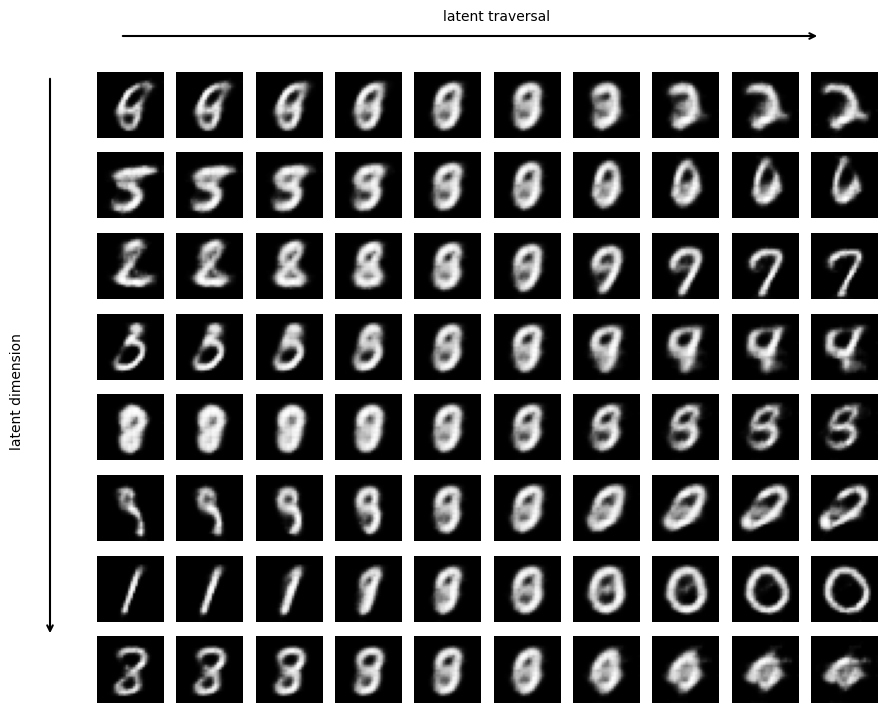

In [ ]:
#| code-fold: true
#| code-summary: Plot code - Latent traversal

fig, ax = plt.subplots(latent_dim, ns, figsize=(ns, latent_dim))
for idx_z in range(latent_dim):

    ns = 10
    values_latent = torch.linspace(-3, 3, ns)    
    z = torch.zeros((ns*ns, latent_dim))
    z[:, idx_z] = values_latent.repeat(ns)    
    
    for i in range(ns):            
        sample = learner.model.decode(z[i].to('cuda').unsqueeze(0)).detach().cpu()
        ax[idx_z, i].imshow(sample[0,0], cmap='gray')
        ax[idx_z, i].axis('off')


###### Visual helpers #####
fig.subplots_adjust(top=0.9, left=0.12)

# ---- Top arrow ----
plt.annotate(
    '', xy=(0.82, 0.85), xytext=(0.12, 0.85),
    xycoords='figure fraction',
    arrowprops=dict(arrowstyle='->', lw=1.5),
    annotation_clip=False
)

plt.text(0.52, 0.96, 'latent traversal', ha='center', va='bottom',
         transform=fig.transFigure)

# ---- Left arrow ----
plt.annotate(
    '', xy=(0.05, 0.1), xytext=(0.05, 0.8),
    xycoords='figure fraction',
    arrowprops=dict(arrowstyle='->', lw=1.5)
)
plt.text(0.04, 0.5, 'latent dimension', ha='center', va='center',
         rotation=90, transform=fig.transFigure);